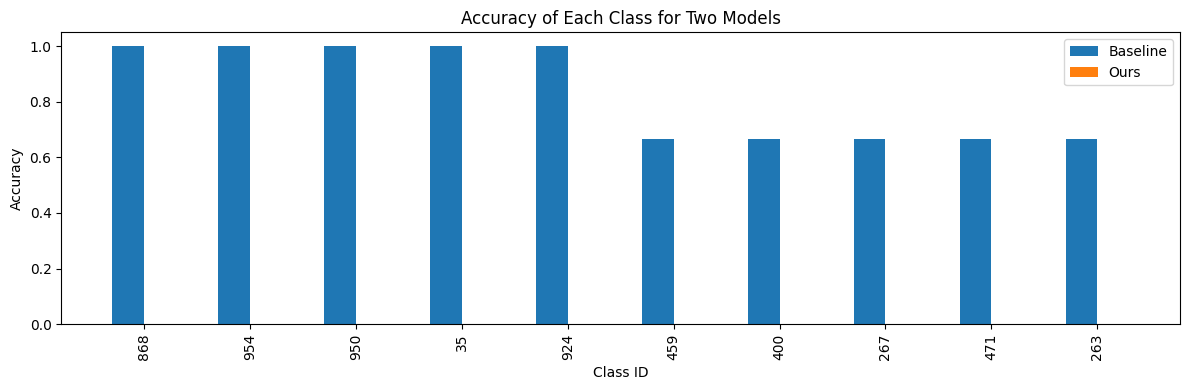

10


In [61]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# Load the JSON data from the two models
file_path_1 = '/home/zhengwei/Desktop/Zhengwei/Projects/CLIP_ReID/logs/visualization_results/marketsketch/class_data.json'
file_path_2 = '/home/zhengwei/Desktop/Zhengwei/Projects/CVAE/outputs/market1k/clipreid_simplevae_tune/novel/2024-07-14/2ndstage_SimpleVAE+2E_128+64z_1e3+3_60+120_KLtotalZ_s2_L1280+CLS_ce+trip+center/visual_results/class_data.json'

with open(file_path_1, 'r') as file:
    data_1 = json.load(file)

with open(file_path_2, 'r') as file:
    data_2 = json.load(file)

q_class_acc_dict_1 = data_1["q_class_acc_dict"]
q_class_path_dict_1 = data_1["q_class_path_dict"]
g_class_path_dict_1 = data_1["g_class_path_dict"]
rank_map_1 = data_1["class_rank1_map_dict"]
# g_class_acc_dict_1 = data_1["g_class_acc_dict"]
# combined_class_acc_dict_1 = {**q_class_acc_dict_1, **g_class_acc_dict_1}

q_class_acc_dict_2 = data_2["q_class_acc_dict"]
q_class_path_dict_2 = data_2["q_class_path_dict"]
g_class_path_dict_2 = data_2["g_class_path_dict"]
rank_map_2 = data_2["class_rank1_map_dict"]
# g_class_acc_dict_2 = data_2["g_class_acc_dict"]
# combined_class_acc_dict_2 = {**q_class_acc_dict_2, **g_class_acc_dict_2}

# Convert dictionaries to DataFrames
df_1 = pd.DataFrame(list(q_class_acc_dict_1.items()), columns=['ClassID', 'Accuracy_1'])
df_2 = pd.DataFrame(list(q_class_acc_dict_2.items()), columns=['ClassID', 'Accuracy_2'])

# Merge DataFrames on ClassID
merged_df = pd.merge(df_1, df_2, on='ClassID')
# Sort by Accuracy_1 for better visualization
merged_df = merged_df.sort_values(by='Accuracy_1', ascending=False)

# Calculate the absolute difference in accuracy
merged_df['Accuracy_Diff'] = (merged_df['Accuracy_1'] - merged_df['Accuracy_2'])

# Define the margin
m = 0.5

# Filter rows where the difference is larger than the margin
filtered_df = merged_df[merged_df['Accuracy_Diff'] > m]
# filtered_df = merged_df

# Display the list of IDs and Accuracy where the difference is larger than the margin
filtered_list = filtered_df[['ClassID', 'Accuracy_1', 'Accuracy_2', 'Accuracy_Diff']].to_dict('records')

# Plot the data with two bins for each class to show the accuracy of each class for the two models
import numpy as np

# Create a DataFrame for the filtered data
filtered_data = pd.DataFrame(filtered_list)

# Plotting the accuracies of each class side by side for the two models
x = np.arange(len(filtered_data['ClassID']))  # the label locations
width = 0.3  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 4))
rects1 = ax.bar(x - width/2, filtered_data['Accuracy_1'], width, label='Baseline')
rects2 = ax.bar(x + width/2, filtered_data['Accuracy_2'], width, label='Ours')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Class ID')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy of Each Class for Two Models')
ax.set_xticks(x)
ax.set_xticklabels(filtered_data['ClassID'],rotation=90)
ax.legend()

fig.tight_layout()

plt.show()
# plt.savefig('class_accuracy_comparison_ours.png')
print(len(filtered_list))
del data_1, data_2


In [58]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import os.path as osp
from PIL import Image, ImageOps
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
def add_border(img, color, border_size=5):
    """Add a border to the image with the specified color and size."""
    return ImageOps.expand(img, border=border_size, fill=color)

def display_images_for_ids(filtered_list, q_class_path_dict_1, g_class_path_dict_1, rank_map_base, rank_map_ours):
    with PdfPages("visualization_base.pdf") as pdf:
        for item in filtered_list:
            class_id = item['ClassID']
            q_img_paths = q_class_path_dict_1.get(class_id, [])
            g_img_paths = g_class_path_dict_1.get(class_id, [])
            # print(rank_map_base[class_id])
            img_paths = q_img_paths + g_img_paths
            query_len = len(q_img_paths)
            gallery_len = len(g_img_paths)
            # img_titles = [f'Class {class_id} - Query', f'Class {class_id} - Gallery']
            plt.figure(figsize=(13, 4))
            print(img_paths)
            for i, img_path in enumerate(img_paths):
                if img_path is not None:
                    # file_name_modified = osp.basename(img_path[0])[:-3]+".jpg"
                    file_name_modified = osp.basename(img_path[0])
                    if i < query_len:
                        img = Image.open(osp.join(sketch_path, file_name_modified)).convert('RGB')
                    else:
                        img = Image.open(osp.join(rgb_path, file_name_modified)).convert('RGB')
                    # Resize the image
                    img = img.resize((128,256))
                    
                    color = 'green' if img_path[1] else 'red'
                    img = add_border(img, color, border_size=2)
                    # Convert image to array
                    img = np.array(img)
                    plt.subplot(1, query_len + gallery_len, i + 1)
                    plt.imshow(img)
                    plt.title("{}".format(file_name_modified[:7]))
                    plt.axis('off')
                    
                    # # Add colored margin
                    # ax = plt.gca()
                    # ax.set_aspect('equal')
                    # color = 'green' if img_path[1] else 'red'
                    # rect = patches.Rectangle((0, 0), img.shape[1], img.shape[0], linewidth=5, edgecolor=color, facecolor='none')
                    # ax.add_patch(rect)
              # Set a general title
            if rank_map_base[class_id]['rank1'] > rank_map_ours[class_id]['rank1']:
                plt.suptitle("$\mathbf{{Base\ R@1/mAP-{:.2f}/{:.2f}}}$ \n Ours R@1/mAP-{:.2f}/{:.2f}".format(
                    rank_map_base[class_id]['rank1'], rank_map_base[class_id]['mAP'],
                    rank_map_ours[class_id]['rank1'], rank_map_ours[class_id]['mAP']), y=1.0)
            else:
                plt.suptitle("Base R@1/mAP-{:.2f}/{:.2f} \n $\mathbf{{Ours\ R@1/mAP-{:.2f}/{:.2f}}}$".format(
                    rank_map_base[class_id]['rank1'], rank_map_base[class_id]['mAP'],
                    rank_map_ours[class_id]['rank1'], rank_map_ours[class_id]['mAP']), y=1.0)
            
            plt.tight_layout() # Adjust the layout
            plt.subplots_adjust(top=0.85)
            pdf.savefig()  # Save the current figure into the PDF
            plt.close()
            # plt.show()
            # break


rgb_path = '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/photo/all'
sketch_path = '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/sketch/fewshot/2sketch/test'
display_images_for_ids(filtered_list, q_class_path_dict_1, g_class_path_dict_1, rank_map_1, rank_map_2)

[['0036_A.jpg', True], ['0036_E.jpg', True], ['0036_F.jpg', True], ['0036_c2s1_002551_00.jpg', True], ['0036_c6s1_003451_00.jpg', True]]
[['0264_C.jpg', True], ['0264_D.jpg', False], ['0264_E.jpg', True], ['0264_c1s1_056006_02.jpg', True], ['0264_c1s1_061881_01.jpg', True]]
[['0268_A.jpg', True], ['0268_C.jpg', True], ['0268_F.jpg', False], ['0268_c4s1_057057_02.jpg', True], ['0268_c5s1_068248_01.jpg', True]]
[['0403_A.jpg', False], ['0403_C.jpg', True], ['0403_E.jpg', True], ['0403_c2s1_096496_05.jpg', True], ['0403_c3s1_096692_02.jpg', True]]
[['0462_A.jpg', True], ['0462_E.jpg', False], ['0462_F.jpg', True], ['0462_c1s2_045246_00.jpg', True], ['0462_c2s1_117466_00.jpg', True]]
[['0474_A.jpg', True], ['0474_B.jpg', False], ['0474_F.jpg', True], ['0474_c3s1_122333_00.jpg', True], ['0474_c5s1_122770_00.jpg', True]]
[['0874_C.jpg', True], ['0874_E.jpg', True], ['0874_c2s3_063652_00.jpg', True], ['0874_c3s3_070019_00.jpg', True]]
[['0931_A.jpg', True], ['0931_E.jpg', True], ['0931_c2s2_1

### Process the retrievaled images according to the difference list

In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import os.path as osp
from PIL import Image, ImageOps
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import json
from matplotlib.gridspec import GridSpec

rgb_path = '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/photo/all'
sketch_path = '/home/zhengwei/Desktop/Zhengwei/Projects/datasets/Market-Sketch-1K/sketch/fewshot/2sketch/test'

def add_border(img, color, border_size=5):
    """Add a border to the image with the specified color and size."""
    return ImageOps.expand(img, border=border_size, fill=color)

def display_images_with_retrieval(filtered_list, rank_results_1, rank_results_2, target_size=(128, 256), pdf_path='ranked_base.pdf'):
    with PdfPages(pdf_path) as pdf:
        for item in filtered_list:
            class_label = item['ClassID']

            # Find all entries in rank_results that match the class label
            matching_entries_1 = [entry for entry in rank_results_1 if int(float(rank_results_1[entry]['label'])) == int(class_label)]
            matching_entries_2 = [entry for entry in rank_results_2 if int(float(rank_results_2[entry]['label'])) == int(class_label)]
            
            # print(matching_entries_1)
            # print(matching_entries_2)
            
            for entry_1, entry_2 in zip(matching_entries_1, matching_entries_2):

                query_info_1 = rank_results_1[str(entry_1)]
                query_img_path = query_info_1['img_name']
                retrieval_img_names_1 = query_info_1['rank_names'][:10]
                retrieval_labels_1 = query_info_1['rank_label'][:10]
                query_label_1 = query_info_1['label']
                
                query_info_2 = rank_results_2[str(entry_2)]
                retrieval_img_names_2 = query_info_2['rank_names'][:10]
                retrieval_labels_2 = query_info_2['rank_label'][:10]
                query_label_2 = query_info_2['label']
            
                if 'home' in query_img_path:
                    query_img_path = osp.basename(query_img_path).replace('pt', 'jpg')
                if 'home' in retrieval_img_names_1[0]:
                    retrieval_img_names_1 = [osp.basename(img_path).replace('pt', 'jpg') for img_path in retrieval_img_names_1]
                if 'home' in retrieval_img_names_2[0]:
                    retrieval_img_names_2 = [osp.basename(img_path).replace('pt', 'jpg') for img_path in retrieval_img_names_2]
            
                plt.figure(figsize=(15, 6.5))
                gs = GridSpec(2, 11, hspace=0.01, wspace=0.05)
                
                # Load and display the query image
                query_img = Image.open(osp.join(sketch_path, query_img_path)).convert('RGB')
                query_img = query_img.resize(target_size)
                query_img = add_border(query_img, 'blue')
                query_img = np.array(query_img)
                
                ax = plt.subplot(gs[0, 0])
                ax.imshow(query_img)
                ax.set_title(f'Base {query_img_path[:-4]}')
                ax.axis('off')
                
                ax = plt.subplot(gs[1, 0])
                ax.imshow(query_img)
                ax.set_title(f'Ours {query_img_path[:-4]}')
                ax.axis('off')

                # Load and display the retrieval images from model 1
                for i, (retrieval_img_name, retrieval_label) in enumerate(zip(retrieval_img_names_1, retrieval_labels_1)):
                    retrieval_img = Image.open(osp.join(rgb_path, retrieval_img_name)).convert('RGB')
                    retrieval_img = retrieval_img.resize(target_size)
                    color = 'green' if retrieval_label == query_label_1 else 'red'
                    retrieval_img = add_border(retrieval_img, color)
                    retrieval_img = np.array(retrieval_img)
                    
                    ax = plt.subplot(gs[0, i + 1])
                    ax.imshow(retrieval_img)
                    ax.set_title(retrieval_img_name[:6])
                    ax.axis('off')
                
                # Load and display the retrieval images from model 2
                for i, (retrieval_img_name, retrieval_label) in enumerate(zip(retrieval_img_names_2, retrieval_labels_2)):
                    retrieval_img = Image.open(osp.join(rgb_path, retrieval_img_name)).convert('RGB')
                    retrieval_img = retrieval_img.resize(target_size)
                    color = 'green' if retrieval_label == query_label_2 else 'red'
                    retrieval_img = add_border(retrieval_img, color)
                    retrieval_img = np.array(retrieval_img)
                    
                    ax = plt.subplot(gs[1, i + 1])
                    ax.imshow(retrieval_img)
                    ax.set_title(retrieval_img_name[:6])
                    ax.axis('off')
                
                plt.tight_layout() # Adjust the layout
                # plt.subplots_adjust(top=0.85)
                pdf.savefig()  # Save the current figure into the PDF
                plt.close()
                # plt.show()
                # break
            # break
ours_json_path = '/home/zhengwei/Desktop/Zhengwei/Projects/CVAE/outputs/market1k/clipreid_simplevae_tune/novel/2024-07-14/2ndstage_SimpleVAE+2E_128+64z_1e3+3_60+120_KLtotalZ_s2_L1280+CLS_ce+trip+center/visual_results/rank_results.json'
baseline_json_path = '/home/zhengwei/Desktop/Zhengwei/Projects/CLIP_ReID/logs/visualization_results/marketsketch/rank_results.json'
# Load rank results from JSON
with open(baseline_json_path, 'r') as file:
    rank_results_1 = json.load(file)

with open(ours_json_path, 'r') as file:
    rank_results_2 = json.load(file)

display_images_with_retrieval(filtered_list, rank_results_1, rank_results_2)
print("Done")

/tmp/ipykernel_3600390/7006132.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout() # Adjust the layout


Done


In [23]:
print(filtered_list)

[{'ClassID': '35', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}, {'ClassID': '263', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '267', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '400', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '459', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '471', 'Accuracy_1': 0.6666666666666666, 'Accuracy_2': 0.0, 'Accuracy_Diff': 0.6666666666666666}, {'ClassID': '868', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}, {'ClassID': '924', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}, {'ClassID': '950', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}, {'ClassID': '954', 'Accuracy_1': 1.0, 'Accuracy_2': 0.0, 'Accuracy_Diff': 1.0}]
